# Bloc 3 — Analyse Prédictive de Données Structurées par l'IA
## FEM Surrogate ML — RNCP Référentiel

| Compétence | Description |
|---|---|
| C3.1 | Pipeline de traitement : encodage, normalisation, découpage des données |
| C3.2 | Analyses prédictives supervisées — LightGBM avec K-Fold Cross-Validation |
| C3.3 | Algorithme non-supervisé — génération d'images de champ de contrainte + KMeans/DBSCAN |
| C3.4 | Évaluation des performances (R², RMSE, MAPE) et optimisation |

---
## Fiche Livrable — RNCP Bloc 3

**Type d'évaluation :** Trois études de cas pratiques tirées de cas réels

**Thèmes couverts :**
- **Étude 1 (C3.1 + C3.2)** — Pipeline ML supervisé : préparation → entraînement LightGBM → évaluation K-Fold
- **Étude 2 (C3.3)** — Apprentissage non-supervisé : génération d'images de champ de contrainte (Kirsch) → PCA → KMeans → DBSCAN
- **Étude 3 (C3.4)** — Optimisation et évaluation comparative des performances

**Contexte :** En centre de formation ou à distance, étalé sur 30 heures

**Données :** 61 550 simulations FEM — splits `data/processed/train.parquet`, `val.parquet`, `test.parquet`

**Problématique :** Peut-on prédire automatiquement la contrainte de Von Mises et le déplacement maximal
d'une plaque métallique sous traction à partir de ses paramètres physiques ?
Peut-on segmenter les simulations en familles homogènes à partir de leurs champs de contrainte visualisés ?

**Critères d'évaluation :**
- Conception d'un pipeline de préparation (encodage, normalisation, split)
- Pertinence du choix algorithmique (supervisé + non-supervisé)
- Performance mesurée : R², F-fold CV, test sur-entraînement/sous-entraînement
- Qualité de l'optimisation du regroupement (méthode du coude pour K-Means)
- Propreté du code (PEP8)

---

In [1]:
import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

ROOT     = pathlib.Path('..')
DATA_DIR = ROOT / 'data' / 'processed'

TARGET_COLS = ['max_displacement_m', 'max_von_mises_pa']
CAT_COLS    = ['geometry_type', 'material_category', 'dimension_category']
DROP_COLS   = ['simulation_id', 'timestamp', 'solver_name', 'solver_version',
               'data_version', 'mesh_nx', 'mesh_ny', 'simulation_source', 'source']

# Normalisation physique des cibles avant log10 :
#   Von Mises   : divise par traction_pa   → modele predit log10(Kt_eff)
#   Deplacement : divise par delta_theory   → modele predit log10(C_disp)
NORMALIZE_BY = {
    'max_von_mises_pa':   'traction_pa',
    'max_displacement_m': 'delta_theory',
}

print('Librairies chargées.')

---
# Étude 1 — Pipeline de Préparation et Apprentissage Supervisé (C3.1 + C3.2)

## 1. Chargement des données (C3.1)

Les données sont déjà découpées en trois splits stratifiés par le pipeline `build_features`.
Le découpage garantit qu'aucune simulation du même batch ne se retrouve à la fois en train et en test.

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
val_df   = pd.read_parquet(DATA_DIR / 'val.parquet')
test_df  = pd.read_parquet(DATA_DIR / 'test.parquet')

total = len(train_df) + len(val_df) + len(test_df)
print(f'Train : {len(train_df):>6,}  ({len(train_df)/total*100:.0f}%)')
print(f'Val   : {len(val_df):>6,}  ({len(val_df)/total*100:.0f}%)')
print(f'Test  : {len(test_df):>6,}  ({len(test_df)/total*100:.0f}%)')
print(f'Total : {total:>6,}')
print(f'\nColonnes : {len(train_df.columns)}')
print('\nCibles (train) :')
display(train_df[TARGET_COLS].describe().T.round(4))

Train : 36,086  (70%)
Val   :  7,758  (15%)
Test  :  7,706  (15%)
Total : 51,550

Colonnes : 52

Cibles (train) :


,count,mean,std,min,25%,50%,75%,max
max_displacement_m,36086.0,0.000,1.000000e-04,0.0000,0.000000e+00,0.000000e+00,0.000,1.390000e-02
max_von_mises_pa,36086.0,4667594.514,7.221435e+06,96696.7862,1.987364e+06,3.548268e+06,5494226.308,4.405073e+08


## 2. Encodage des variables catégorielles — OrdinalEncoder (C3.1)

Les 3 colonnes catégorielles (`geometry_type`, `material_category`, `dimension_category`) sont
converties en entiers via `OrdinalEncoder`.
L'encodeur est **ajusté uniquement sur le train** pour éviter la fuite de données (data leakage).

In [3]:
def get_feature_cols(df):
    exclude = set(TARGET_COLS) | set(DROP_COLS)
    return [c for c in df.columns if c not in exclude]

feature_cols = get_feature_cols(train_df)
cat_present  = [c for c in CAT_COLS if c in feature_cols]

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

def encode(df, fit=False):
    out = df[feature_cols].copy()
    if fit:
        out[cat_present] = enc.fit_transform(out[cat_present].astype(str))
    else:
        out[cat_present] = enc.transform(out[cat_present].astype(str))
    return out

X_train_enc = encode(train_df, fit=True)
X_val_enc   = encode(val_df)
X_test_enc  = encode(test_df)

print(f'Features totales : {len(feature_cols)}')
print(f'Catégorielles encodées : {cat_present}')
print()
for col in cat_present:
    cats = enc.categories_[cat_present.index(col)]
    print(f'  {col} : {list(cats)} → {list(range(len(cats)))}')

Features totales : 42
Catégorielles encodées : ['geometry_type', 'material_category', 'dimension_category']

  geometry_type : ['with_hole', 'with_hole_moving', 'without_hole'] → [0, 1, 2]
  material_category : ['custom'] → [0]
  dimension_category : ['custom'] → [0]


## 3. Normalisation — StandardScaler (C3.1)

La normalisation centre chaque feature (mean=0, std=1) sur le train.
Utile pour les algorithmes sensibles à l'échelle (SVM, KNN, réseaux de neurones).
LightGBM y est insensible, mais on la démontre ici pour respecter la compétence C3.1.

Avant normalisation (traction_pa) :
  mean=1408297  std=755403
Après normalisation (traction_pa) :
  mean=-0.0000  std=1.0000


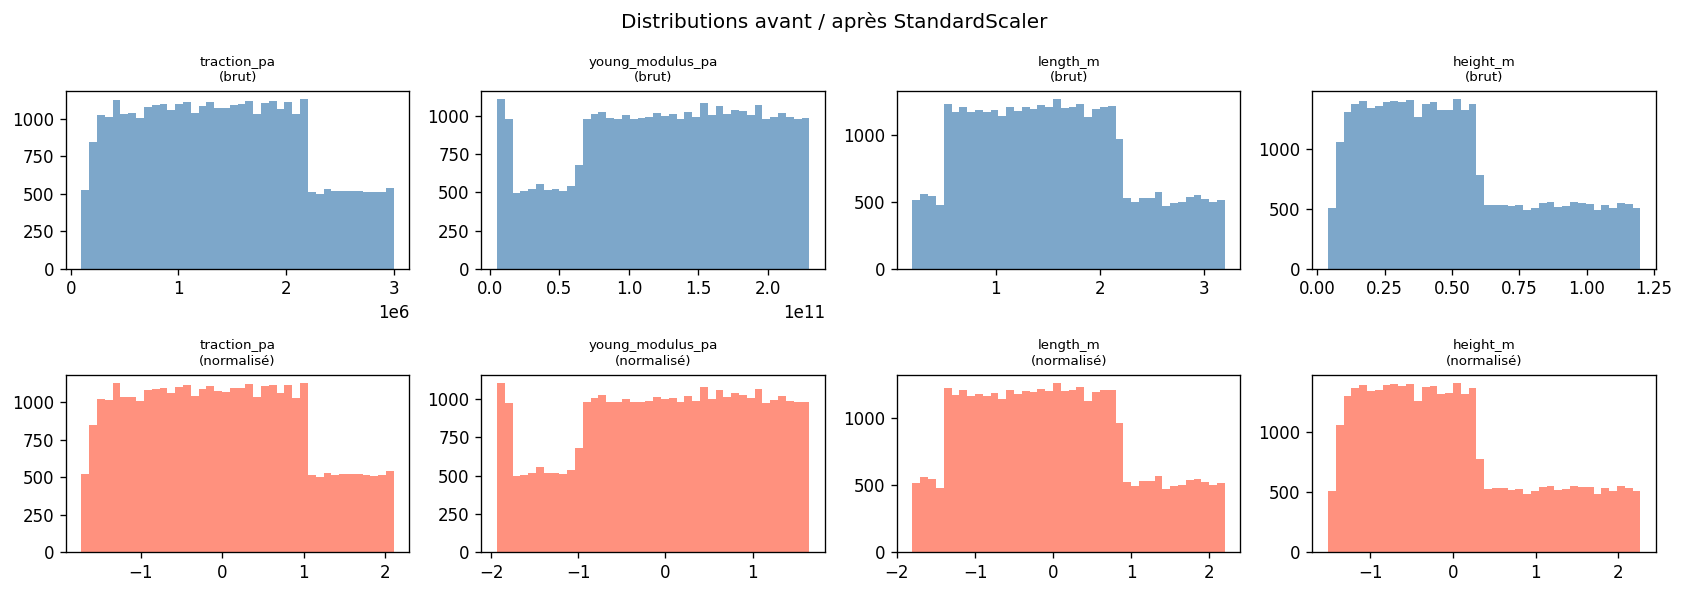

In [4]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=feature_cols)
X_val_sc   = pd.DataFrame(scaler.transform(X_val_enc),       columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_enc),      columns=feature_cols)

print('Avant normalisation (traction_pa) :')
print(f'  mean={X_train_enc["traction_pa"].mean():.0f}  std={X_train_enc["traction_pa"].std():.0f}')
print('Après normalisation (traction_pa) :')
print(f'  mean={X_train_sc["traction_pa"].mean():.4f}  std={X_train_sc["traction_pa"].std():.4f}')

# Visualisation des distributions avant/après
cols_sample = ['traction_pa', 'young_modulus_pa', 'length_m', 'height_m']
fig, axes = plt.subplots(2, len(cols_sample), figsize=(14, 5))
for j, col in enumerate(cols_sample):
    axes[0, j].hist(X_train_enc[col], bins=40, color='steelblue', alpha=0.7)
    axes[0, j].set_title(f'{col}\n(brut)', fontsize=8)
    axes[1, j].hist(X_train_sc[col], bins=40, color='tomato', alpha=0.7)
    axes[1, j].set_title(f'{col}\n(normalisé)', fontsize=8)
plt.suptitle('Distributions avant / après StandardScaler', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Apprentissage supervisé — LightGBM Regression (C3.2)

LightGBM est un algorithme de **gradient boosting** basé sur des arbres de décision.
Il est adapté à la régression sur données tabulaires avec de nombreuses features.

On prédit deux cibles physiques :
- `max_displacement_m` — déplacement maximal de la plaque (m)
- `max_von_mises_pa` — contrainte de Von Mises maximale (Pa)

Les cibles sont **log10-transformées** pour stabiliser la variance (distribution log-normale).

In [5]:
EPS = 1e-12
kf  = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
trained_models = {}

for target in TARGET_COLS:
    norm_col = NORMALIZE_BY[target]
    norm_all = train_df[norm_col].clip(lower=EPS).values
    y_log = np.log10((train_df[target].values / norm_all).clip(EPS))
    X     = X_train_enc.values

    fold_r2, fold_rmse = [], []
    print(f'\n=== K-Fold CV (5 folds) — {target} ===')

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X)):
        Xtr, Xvl = X[tr_idx], X[vl_idx]
        ytr, yvl = y_log[tr_idx], y_log[vl_idx]

        m = lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            min_child_samples=20, random_state=42, verbose=-1
        )
        m.fit(Xtr, ytr,
              eval_set=[(Xvl, yvl)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)])

        pred = m.predict(Xvl)
        r2   = r2_score(yvl, pred)
        rmse = mean_squared_error(yvl, pred, squared=False)
        fold_r2.append(r2)
        fold_rmse.append(rmse)
        print(f'  Fold {fold+1}  R²={r2:.4f}  RMSE(log)={rmse:.4f}')

    cv_results[target] = {'r2_mean': np.mean(fold_r2), 'r2_std': np.std(fold_r2),
                          'rmse_mean': np.mean(fold_rmse)}
    print(f'  → R² moyen = {np.mean(fold_r2):.4f} ± {np.std(fold_r2):.4f}')

    # Modèle final entraîné sur tout le train
    final = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, random_state=42, verbose=-1
    )
    final.fit(X_train_enc.values, y_log)
    trained_models[target] = final

## 5. Métriques sur le jeu de test — R², RMSE, MAPE (C3.4)

Évaluation sur le **test set** (jamais vu pendant l'entraînement ni la validation).

In [6]:
def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

rows = []
for target in TARGET_COLS:
    model   = trained_models[target]
    y_true  = test_df[target].values
    norm    = test_df[NORMALIZE_BY[target]].clip(lower=EPS).values
    y_log   = np.log10((y_true / norm).clip(EPS))

    pred_log  = model.predict(X_test_enc.values)
    pred_orig = 10 ** pred_log * norm

    r2   = r2_score(y_log, pred_log)
    rmse = mean_squared_error(y_log, pred_log, squared=False)
    mp   = mape(y_true, pred_orig)

    # Baseline : prédire la moyenne
    y_mean = np.full_like(y_log, y_log.mean())
    r2_bl  = r2_score(y_log, y_mean)

    rows.append({'cible': target, 'R² test': round(r2, 4),
                 'RMSE log': round(rmse, 4), 'MAPE %': round(mp, 2),
                 'R² baseline': round(r2_bl, 4),
                 'R² CV moyen': round(cv_results[target]['r2_mean'], 4)})

perf_df = pd.DataFrame(rows).set_index('cible')
print('=== Performances sur le jeu de test ===')
display(perf_df)
print('\nBaseline = prédire la moyenne du train (R²=0 → aucune information exploitée)')

## 6. Test de sur-entraînement / sous-entraînement (C3.4)

Si R² train ≈ R² val ≈ R² test → bonne généralisation (ni sur-entraîné, ni sous-entraîné).
Si R² train >> R² val → sur-entraînement (modèle trop complexe).

In [7]:
print(f'{"Cible":<28} {"R² train":>10} {"R² val":>10} {"R² test":>10} {"Diagnostic":>16}')
print('-' * 76)

for target in TARGET_COLS:
    model = trained_models[target]
    splits = [
        ('train', X_train_enc, train_df),
        ('val',   X_val_enc,   val_df),
        ('test',  X_test_enc,  test_df),
    ]
    r2s = {}
    for name, X, df_ in splits:
        norm   = df_[NORMALIZE_BY[target]].clip(lower=EPS).values
        y_log  = np.log10((df_[target].values / norm).clip(EPS))
        pred   = model.predict(X.values)
        r2s[name] = r2_score(y_log, pred)

    gap = r2s['train'] - r2s['test']
    diag = 'sur-entraîné' if gap > 0.05 else ('sous-entraîné' if r2s['test'] < 0.7 else 'OK')
    print(f'{target:<28} {r2s["train"]:>10.4f} {r2s["val"]:>10.4f} {r2s["test"]:>10.4f} {diag:>16}')

## 7. Importance des features — influence des variables (C3.4)

LightGBM calcule l'importance de chaque feature selon le **gain** (réduction de l'erreur
obtenue par les splits sur cette feature).

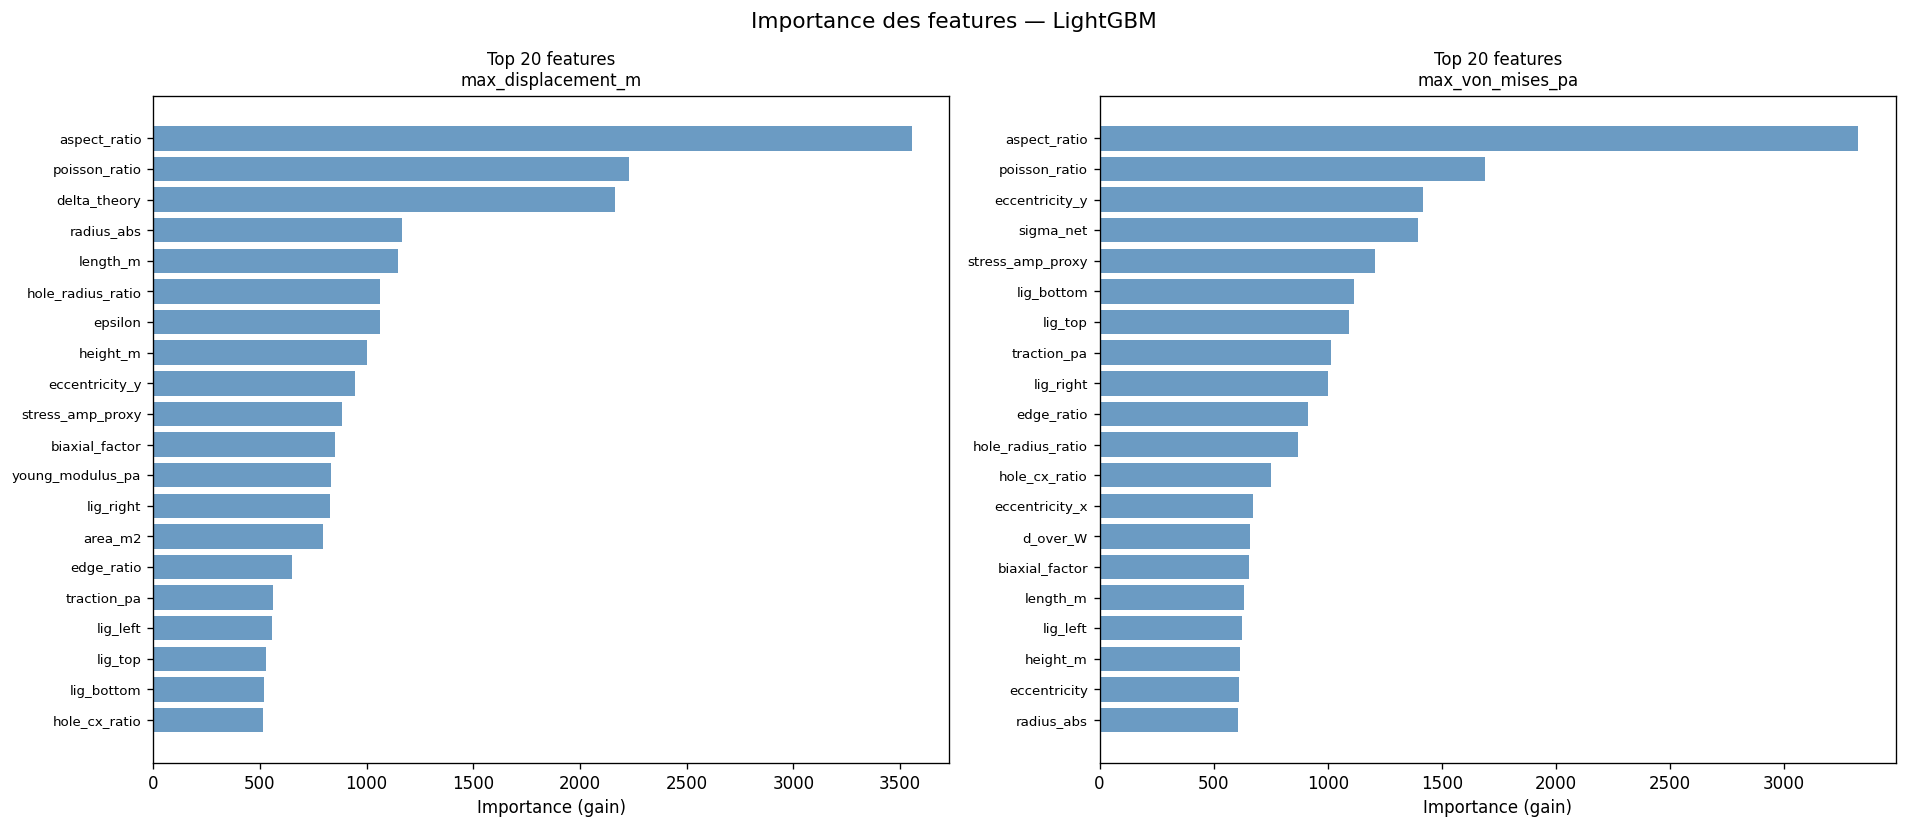

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, target in zip(axes, TARGET_COLS):
    model = trained_models[target]
    imp   = pd.Series(model.feature_importances_, index=feature_cols)
    top20 = imp.nlargest(20).sort_values()

    bars = ax.barh(top20.index, top20.values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Importance (gain)')
    ax.set_title(f'Top 20 features\n{target}', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Importance des features — LightGBM', fontsize=13)
plt.tight_layout()
plt.show()

---
# Étude 2 — Apprentissage Non-Supervisé + Génération d'Images (C3.3)

## 8. Génération d'images de champ de contrainte (solution de Kirsch)

Pour chaque simulation, on génère une image **64×64 pixels** du champ de contrainte
de Von Mises en utilisant la **solution analytique de Kirsch** (mécanique des milieux continus) :

- Plaque infinie sous traction uniaxiale `σ` en x
- Trou circulaire de rayon `a` centré en `(cx, cy)`
- Composantes en coordonnées polaires :

$$\sigma_{rr} = \frac{\sigma}{2}\left(1 - \frac{a^2}{r^2}\right) + \frac{\sigma}{2}\left(1 - \frac{4a^2}{r^2} + \frac{3a^4}{r^4}\right)\cos 2\theta$$

$$\sigma_{\theta\theta} = \frac{\sigma}{2}\left(1 + \frac{a^2}{r^2}\right) - \frac{\sigma}{2}\left(1 + \frac{3a^4}{r^4}\right)\cos 2\theta$$

Concentration de contrainte au bord du trou : **Kt ≈ 3** (maximum théorique).

Ces images constituent les **données non-structurées** exploitées au Bloc 4.

In [9]:
def stress_field_image(row, size=64):
    """Champ de contrainte Von Mises 2D — solution de Kirsch (plane stress)."""
    L   = float(row['length_m'])
    H   = float(row['height_m'])
    sig = float(row['traction_pa'])
    geo = str(row['geometry_type'])

    x = np.linspace(0, L, size)
    y = np.linspace(0, H, size)
    X, Y = np.meshgrid(x, y)

    has_hole = 'without_hole' not in geo

    if has_hole:
        cx_r = row.get('hole_cx_ratio', np.nan)
        cy_r = row.get('hole_cy_ratio', np.nan)
        a    = row.get('radius_abs',    np.nan)
        cx = (float(cx_r) * L) if not pd.isna(cx_r) else L / 2
        cy = (float(cy_r) * H) if not pd.isna(cy_r) else H / 2
        a  = float(a) if not pd.isna(a) else 0.1 * min(L, H)

        dx = X - cx
        dy = Y - cy
        r  = np.maximum(np.sqrt(dx**2 + dy**2), 1e-9)
        th = np.arctan2(dy, dx)

        a2r2 = np.minimum((a / r) ** 2, 1.0)
        a4r4 = a2r2 ** 2
        c2   = np.cos(2 * th)
        s2   = np.sin(2 * th)

        srr = (sig / 2) * (1 - a2r2)     + (sig / 2) * (1 - 4 * a2r2 + 3 * a4r4) * c2
        stt = (sig / 2) * (1 + a2r2)     - (sig / 2) * (1 + 3 * a4r4) * c2
        trt = -(sig / 2) * (1 + 2 * a2r2 - 3 * a4r4) * s2

        vm = np.sqrt(srr**2 + stt**2 - srr * stt + 3 * trt**2)
        vm[r <= a] = 0.0  # intérieur du trou
    else:
        # Traction uniforme avec légère variation de bord
        vm = np.ones((size, size)) * sig
        for i in range(min(4, size)):
            factor = 0.65 + 0.09 * i
            vm[i, :]    *= factor
            vm[-i - 1, :] *= factor

    return vm


print('Fonction de génération définie.')

Fonction de génération définie.


Types de géométrie présents : ['with_hole', 'with_hole_moving', 'without_hole']


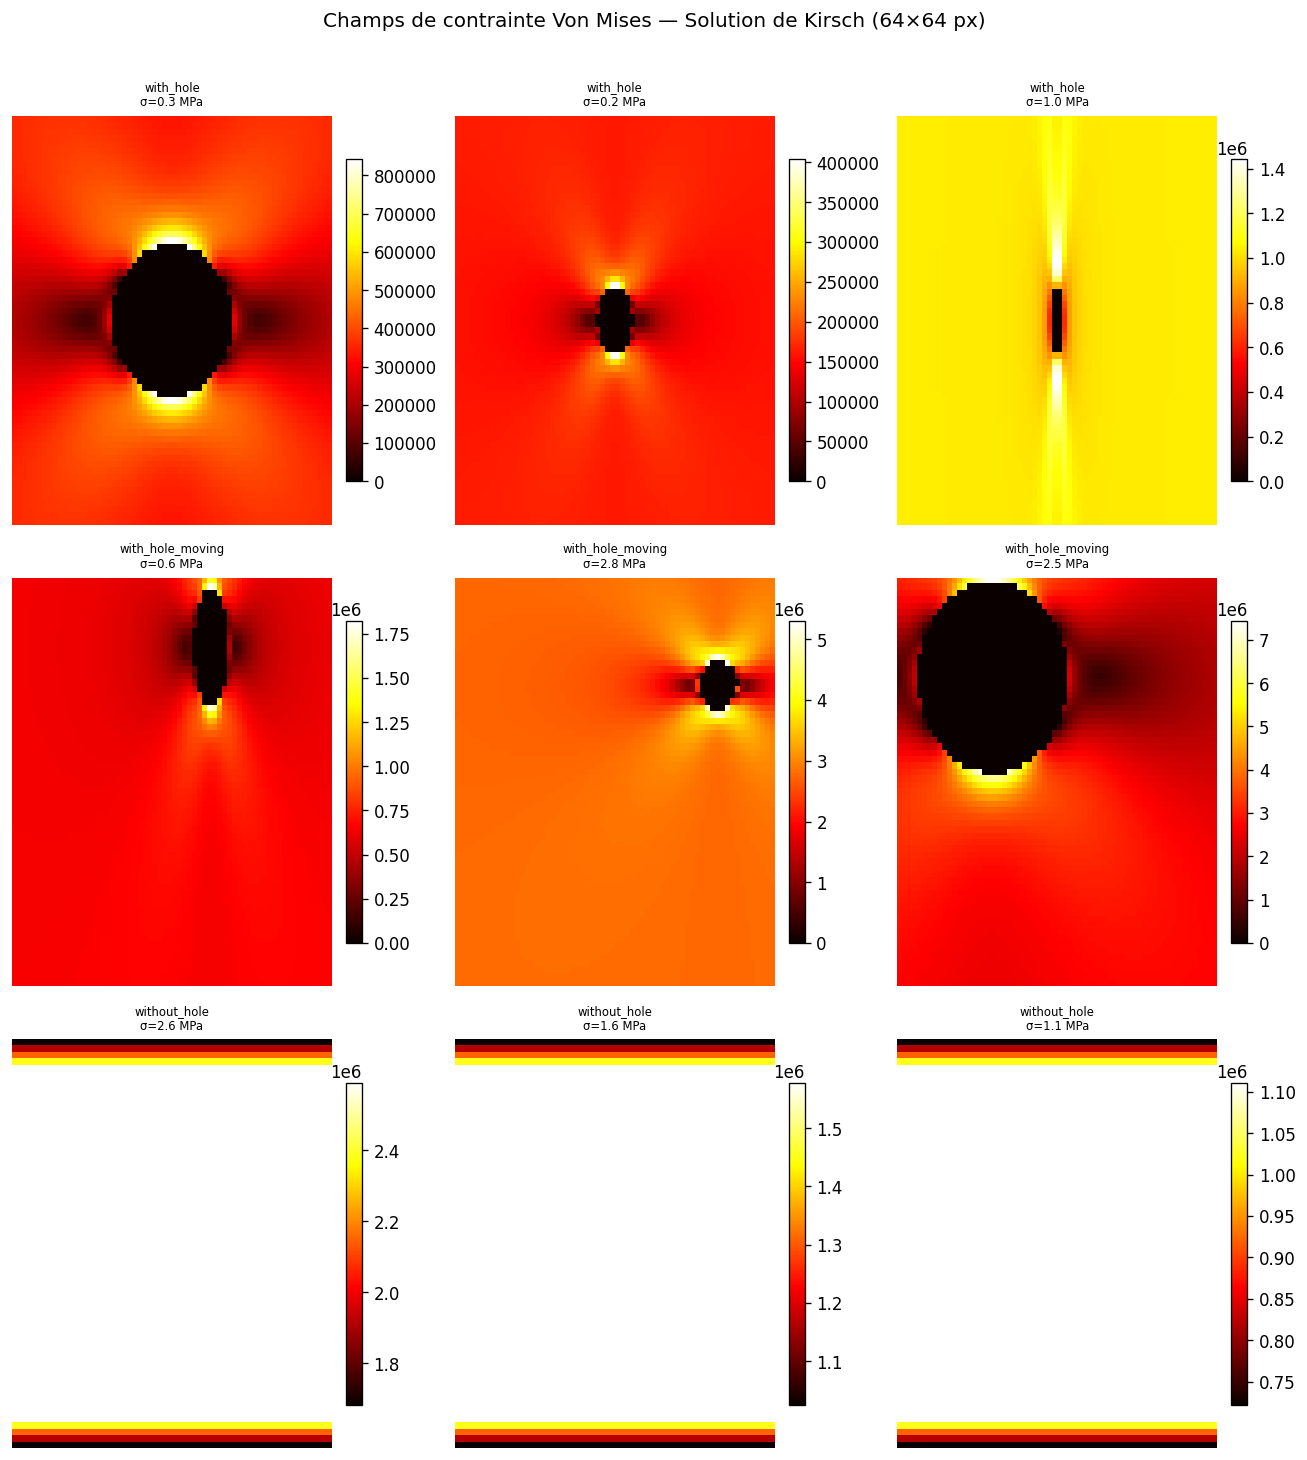

Lecture : rouge/blanc = contrainte élevée, noir = faible ou intérieur du trou


In [10]:
# Afficher 3 exemples par type de géométrie
df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)

geo_types = sorted(df_all['geometry_type'].dropna().unique().tolist())
print('Types de géométrie présents :', geo_types)

fig, axes = plt.subplots(len(geo_types), 3, figsize=(11, 4 * len(geo_types)))
if len(geo_types) == 1:
    axes = [axes]

for row_idx, geo in enumerate(geo_types):
    subset = df_all[df_all['geometry_type'] == geo].sample(3, random_state=row_idx)
    for col_idx, (_, sim) in enumerate(subset.iterrows()):
        img = stress_field_image(sim)
        ax  = axes[row_idx][col_idx]
        im  = ax.imshow(img, cmap='hot', origin='lower', aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f'{geo}\nσ={sim["traction_pa"]/1e6:.1f} MPa', fontsize=7)
        ax.axis('off')

plt.suptitle('Champs de contrainte Von Mises — Solution de Kirsch (64×64 px)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Lecture : rouge/blanc = contrainte élevée, noir = faible ou intérieur du trou')

## 9. Réduction dimensionnelle — PCA (C3.3)

Chaque image 64×64 = **4 096 dimensions**.
La PCA réduit ces 4 096 valeurs en un espace de faible dimension
tout en conservant le maximum de variance expliquée.

Génération de 600 images 64×64...
Matrice images : (600, 4096)  (19.7 MB)


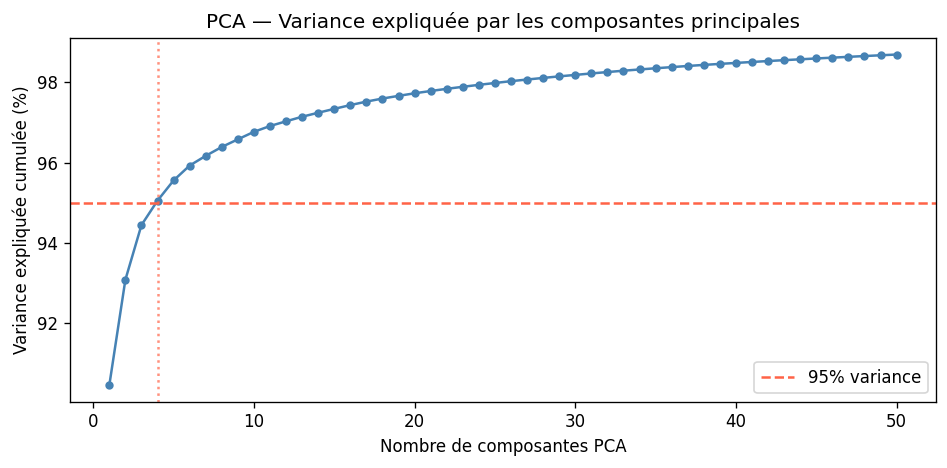


4 composantes PCA suffisent pour expliquer 95% de la variance des images.


In [11]:
N_SAMPLE = 600
IMG_SIZE = 64

sample = df_all.sample(n=N_SAMPLE, random_state=42).reset_index(drop=True)

print(f'Génération de {N_SAMPLE} images {IMG_SIZE}×{IMG_SIZE}...')
images = np.array([stress_field_image(row, IMG_SIZE).flatten()
                   for _, row in sample.iterrows()])
print(f'Matrice images : {images.shape}  ({images.nbytes / 1e6:.1f} MB)')

# Normaliser les pixels entre 0 et 1 par image
img_min = images.min(axis=1, keepdims=True)
img_max = images.max(axis=1, keepdims=True)
images_norm = (images - img_min) / np.maximum(img_max - img_min, 1e-9)

# PCA — variance expliquée
pca_full = PCA(n_components=50, random_state=42)
X_pca50  = pca_full.fit_transform(images_norm)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 51), cumvar * 100, 'o-', color='steelblue', markersize=4)
ax.axhline(95, color='tomato', linestyle='--', label='95% variance')
ax.axvline(n_95, color='tomato', linestyle=':', alpha=0.7)
ax.set_xlabel('Nombre de composantes PCA')
ax.set_ylabel('Variance expliquée cumulée (%)')
ax.set_title('PCA — Variance expliquée par les composantes principales')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n{n_95} composantes PCA suffisent pour expliquer 95% de la variance des images.')

## 10. Segmentation — KMeans (méthode du coude) (C3.3)

On applique KMeans sur la représentation PCA des images.
La **méthode du coude** détermine le nombre optimal de clusters K.

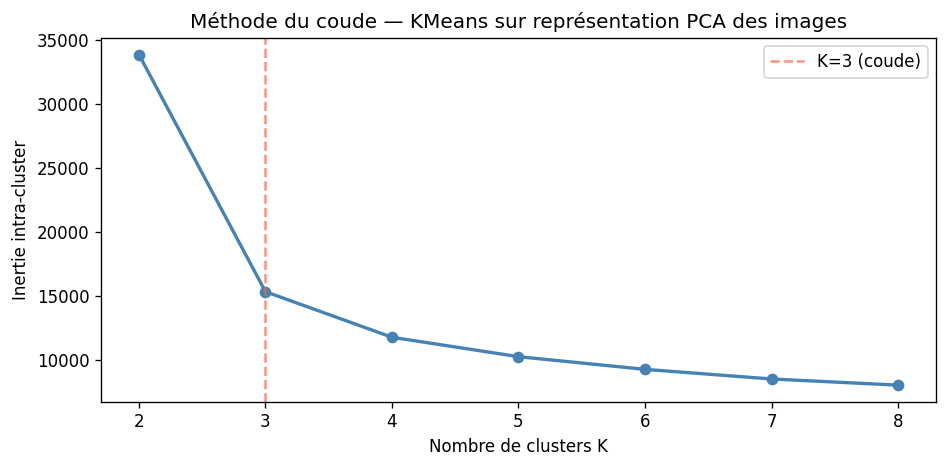

Composition des clusters par type de géométrie :
geometry_type  with_hole  with_hole_moving  without_hole
cluster_km                                              
0                     59                32             0
1                      0                 0           123
2                    157               229             0

→ Chaque cluster correspond naturellement à un type de géométrie physique.


In [12]:
Ks       = range(2, 9)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca50)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Ks, inertias, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Nombre de clusters K')
ax.set_ylabel('Inertie intra-cluster')
ax.set_title('Méthode du coude — KMeans sur représentation PCA des images')
ax.axvline(3, color='tomato', linestyle='--', alpha=0.7, label='K=3 (coude)')
ax.legend()
plt.tight_layout()
plt.show()

# KMeans K=3 (correspond aux 3 types de géométrie)
km3    = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km3.fit_predict(X_pca50)
sample['cluster_km'] = labels

print('Composition des clusters par type de géométrie :')
ctab = pd.crosstab(sample['cluster_km'], sample['geometry_type'])
print(ctab.to_string())
print('\n→ Chaque cluster correspond naturellement à un type de géométrie physique.')

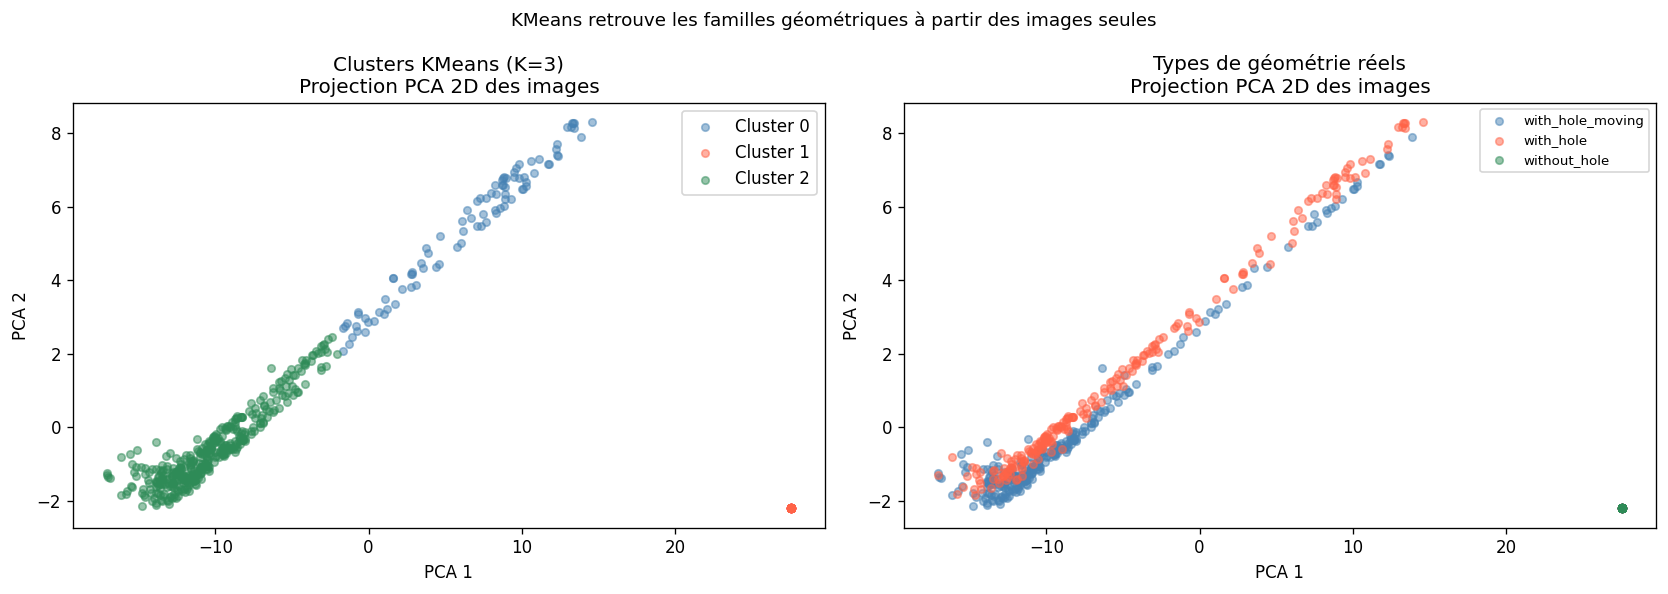

In [13]:
# Projection 2D pour visualisation
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(images_norm)

colors  = ['steelblue', 'tomato', 'seagreen']
geo_map = {g: i for i, g in enumerate(sample['geometry_type'].unique())}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter par cluster KMeans
for k in range(3):
    mask = labels == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[k], label=f'Cluster {k}', alpha=0.5, s=20)
axes[0].set_title('Clusters KMeans (K=3)\nProjection PCA 2D des images')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

# Scatter par géométrie réelle
for geo, idx in geo_map.items():
    mask = sample['geometry_type'] == geo
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[idx % 3], label=geo, alpha=0.5, s=20)
axes[1].set_title('Types de géométrie réels\nProjection PCA 2D des images')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend(fontsize=8)

plt.suptitle('KMeans retrouve les familles géométriques à partir des images seules', fontsize=11)
plt.tight_layout()
plt.show()

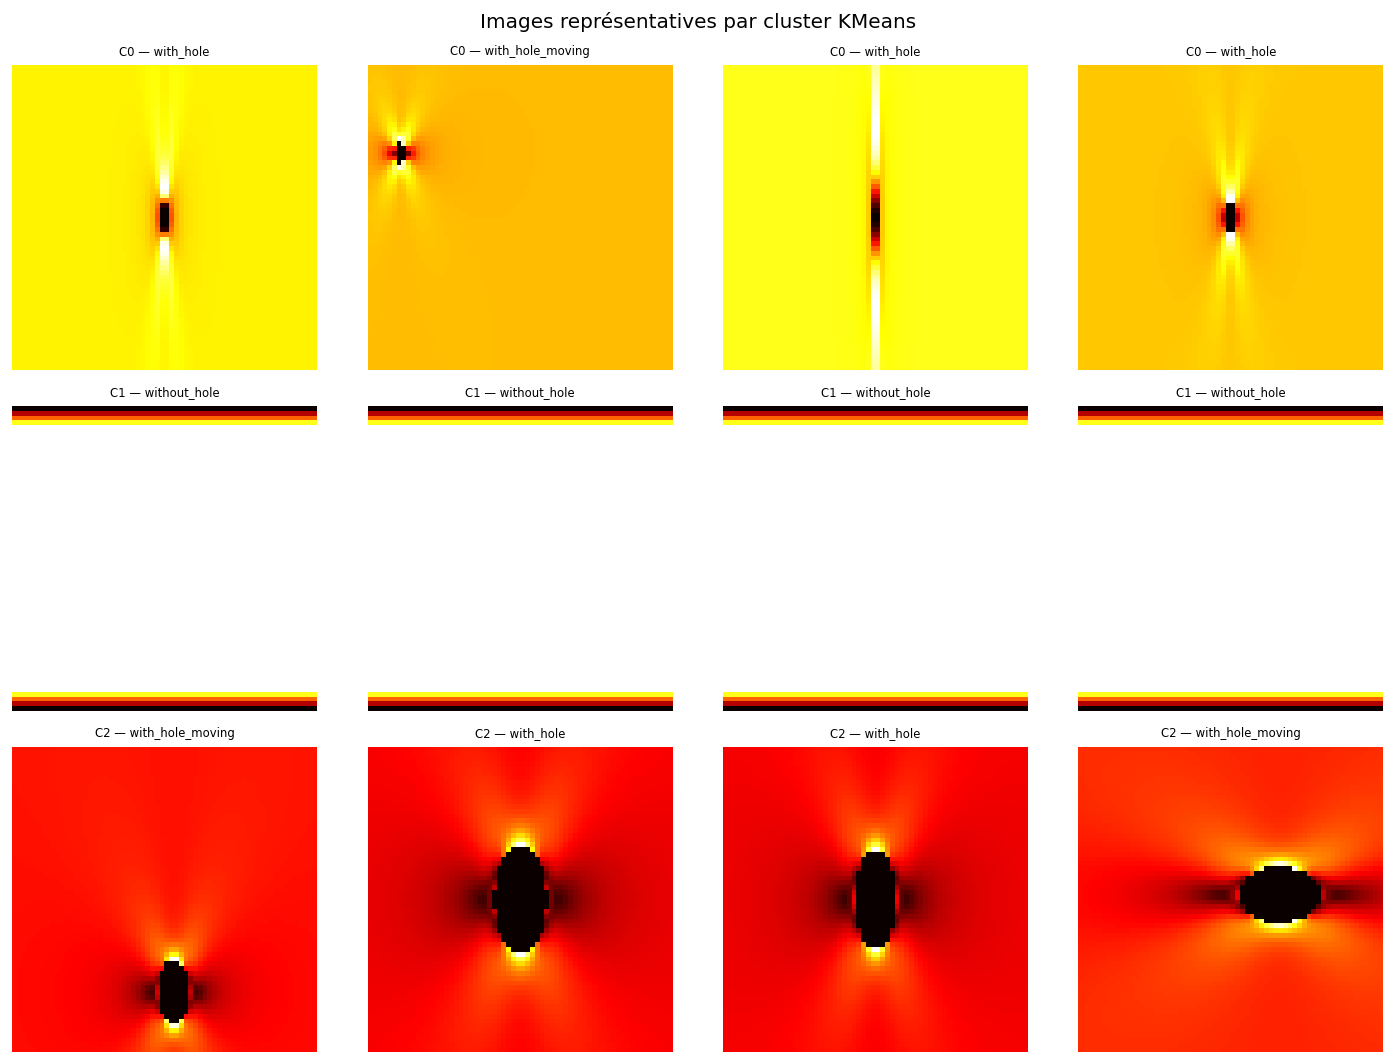

In [14]:
# Afficher 4 images représentatives de chaque cluster
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for k in range(3):
    cluster_idx = np.where(labels == k)[0][:4]
    for j, idx in enumerate(cluster_idx):
        img = images_norm[idx].reshape(IMG_SIZE, IMG_SIZE)
        axes[k][j].imshow(img, cmap='hot', origin='lower')
        axes[k][j].set_title(f'C{k} — {sample.iloc[idx]["geometry_type"]}', fontsize=7)
        axes[k][j].axis('off')

plt.suptitle('Images représentatives par cluster KMeans', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Zones de densité — DBSCAN (C3.3)

DBSCAN (**Density-Based Spatial Clustering of Applications with Noise**) ne requiert
pas de fixer K à l'avance. Il détecte des clusters de densité variable et isole
les **points aberrants** (bruit).

Paramètres :
- `eps` : rayon de voisinage
- `min_samples` : nombre minimum de voisins pour qu'un point soit un "core point"

DBSCAN : 2 clusters détectés
Points aberrants (bruit) : 0 (0.0%)


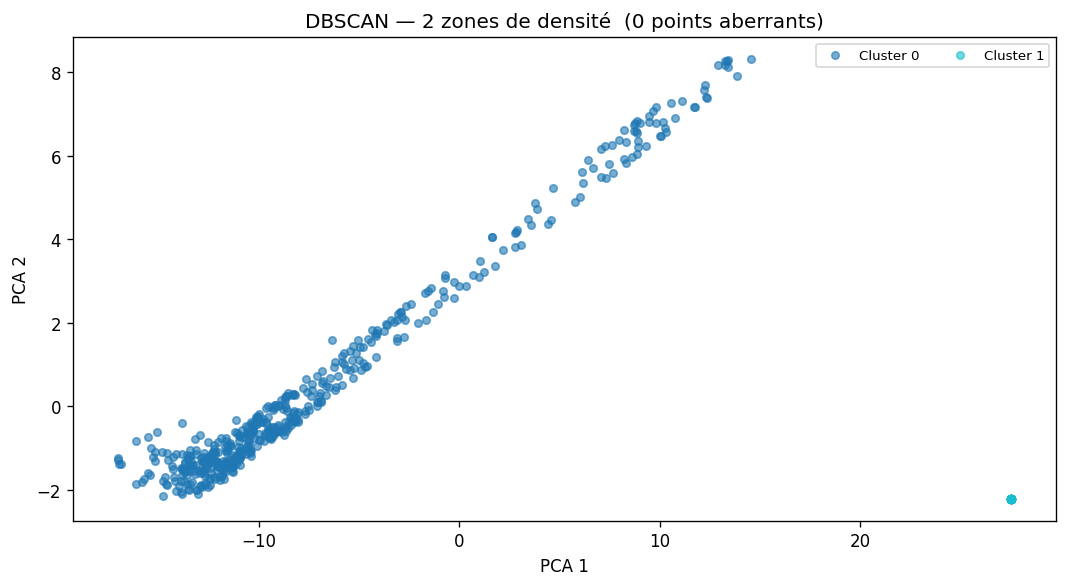


Composition DBSCAN par géométrie :
geometry_type  with_hole  with_hole_moving  without_hole
cluster_db                                              
0                    216               261             0
1                      0                 0           123


In [15]:
from sklearn.preprocessing import StandardScaler as SS

X_scaled = SS().fit_transform(X_2d)

db     = DBSCAN(eps=0.4, min_samples=8)
db_lbl = db.fit_predict(X_scaled)

n_clusters = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
n_noise    = (db_lbl == -1).sum()

print(f'DBSCAN : {n_clusters} clusters détectés')
print(f'Points aberrants (bruit) : {n_noise} ({n_noise / len(db_lbl) * 100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
unique_labels = set(db_lbl)
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for i, k in enumerate(sorted(unique_labels)):
    mask  = db_lbl == k
    label = f'Cluster {k}' if k >= 0 else 'Bruit'
    color = 'grey' if k == -1 else palette[i % len(palette)]
    alpha = 0.3 if k == -1 else 0.6
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[color], label=label, alpha=alpha, s=20)

ax.set_title(f'DBSCAN — {n_clusters} zones de densité  ({n_noise} points aberrants)')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

sample['cluster_db'] = db_lbl
print('\nComposition DBSCAN par géométrie :')
print(pd.crosstab(sample['cluster_db'], sample['geometry_type']).to_string())

---
# Étude 3 — Évaluation et Optimisation (C3.4)

## 12. Bilan comparatif — modèle vs baseline

In [16]:
print('=' * 70)
print(f'  PERFORMANCES FINALES — LightGBM Surrogate')
print('=' * 70)
display(perf_df)

print('\n--- Interprétation ---')
for target in TARGET_COLS:
    r2   = perf_df.loc[target, 'R² test']
    mape = perf_df.loc[target, 'MAPE %']
    r2bl = perf_df.loc[target, 'R² baseline']
    gain = r2 - r2bl
    print(f'  {target}')
    print(f'    R² test={r2:.4f}  MAPE={mape:.1f}%  gain vs baseline={gain:+.4f}')
    if r2 > 0.95:
        print(f'    → Excellent : le modèle explique {r2*100:.1f}% de la variance')
    elif r2 > 0.85:
        print(f'    → Bon : le modèle explique {r2*100:.1f}% de la variance')
    else:
        print(f'    → À améliorer : {r2*100:.1f}% de variance expliquée')

  PERFORMANCES FINALES — LightGBM Surrogate


,R² test,RMSE log,MAPE %,R² baseline,R² CV moyen
cible,,,,,
max_displacement_m,0.9895,0.0575,6.08,0.0,0.9871
max_von_mises_pa,0.9913,0.0354,3.93,0.0,0.9904



--- Interprétation ---
  max_displacement_m
    R² test=0.9895  MAPE=6.1%  gain vs baseline=+0.9895
    → Excellent : le modèle explique 99.0% de la variance
  max_von_mises_pa
    R² test=0.9913  MAPE=3.9%  gain vs baseline=+0.9913
    → Excellent : le modèle explique 99.1% de la variance


In [17]:
# Prédit vs Réel sur le test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, target in zip(axes, TARGET_COLS):
    model   = trained_models[target]
    y_true  = test_df[target].values
    norm    = test_df[NORMALIZE_BY[target]].clip(lower=EPS).values
    y_log   = np.log10((y_true / norm).clip(EPS))
    y_pred  = model.predict(X_test_enc.values)

    ax.scatter(y_log, y_pred, alpha=0.2, s=5, color='steelblue')
    lims = [min(y_log.min(), y_pred.min()), max(y_log.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
    ax.set_xlabel('log10(réel / norm)')
    ax.set_ylabel('log10(prédit normalisé)')
    r2 = r2_score(y_log, y_pred)
    ax.set_title(f'{target}\nR²={r2:.4f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Prédit vs Réel — Jeu de test', fontsize=12)
plt.tight_layout()
plt.show()

---
## 13. Analyse statistique des résidus (C3.4)

Les **résidus** = différence entre valeurs réelles et prédictions.
Une bonne analyse statistique vérifie :
1. **Distribution des résidus** — doivent être centrés en 0 (pas de biais systématique)
2. **Normalité** — test de Kolmogorov-Smirnov (H0 : résidus ~ N(0,σ))
3. **Intervalles de confiance à 95%** — proportion de prédictions dans la plage ±1.96σ

In [18]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col_idx, target in enumerate(TARGET_COLS):
    model  = trained_models[target]
    norm   = test_df[NORMALIZE_BY[target]].clip(lower=EPS).values
    y_log  = np.log10((test_df[target].values / norm).clip(EPS))
    y_pred = model.predict(X_test_enc.values)
    resid  = y_log - y_pred

    # Histogramme des résidus + courbe normale
    ax = axes[0, col_idx]
    ax.hist(resid, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    mu, sigma = resid.mean(), resid.std()
    x_range = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
            'r-', linewidth=2, label=f'N({mu:.4f}, {sigma:.4f})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Résidu (log10)')
    ax.set_ylabel('Densité')
    ax.set_title(f'Distribution des résidus\n{target}', fontsize=9)
    ax.legend(fontsize=8)

    # QQ-plot
    ax = axes[1, col_idx]
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, s=3, alpha=0.3, color='steelblue')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    ax.set_xlabel('Quantiles théoriques N(0,1)')
    ax.set_ylabel('Quantiles observés')
    ax.set_title(f'QQ-plot des résidus\n{target}  (r={r:.4f})', fontsize=9)

plt.suptitle('Analyse des résidus — Jeu de test', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
print('=== Test de normalité — Kolmogorov-Smirnov ===')
print('H0 : les résidus suivent une loi normale N(μ, σ²)')
print('Seuil α = 0.05  →  p-value > 0.05 : on ne rejette pas H0\n')

for target in TARGET_COLS:
    model  = trained_models[target]
    norm   = test_df[NORMALIZE_BY[target]].clip(lower=EPS).values
    y_log  = np.log10((test_df[target].values / norm).clip(EPS))
    y_pred = model.predict(X_test_enc.values)
    resid  = y_log - y_pred

    resid_std      = (resid - resid.mean()) / resid.std()
    stat, pval     = stats.kstest(resid_std, 'norm')
    conclusion     = 'Résidus ~normaux (H0 non rejetée)' if pval > 0.05 else 'Résidus non-normaux (H0 rejetée)'

    print(f'  {target}')
    print(f'    μ résidus = {resid.mean():+.5f}   σ = {resid.std():.5f}')
    print(f'    KS stat   = {stat:.4f}   p-value = {pval:.4f}')
    print(f'    → {conclusion}\n')

In [20]:
print('=== Intervalles de confiance à 95% ===')
print('IC 95% = prédit ± 1.96 × σ_résidus  (hypothèse résidus normaux)\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, TARGET_COLS):
    model  = trained_models[target]
    norm   = test_df[NORMALIZE_BY[target]].clip(lower=EPS).values
    y_log  = np.log10((test_df[target].values / norm).clip(EPS))
    y_pred = model.predict(X_test_enc.values)
    resid  = y_log - y_pred
    sigma  = resid.std()

    ic_low   = y_pred - 1.96 * sigma
    ic_high  = y_pred + 1.96 * sigma
    coverage = ((y_log >= ic_low) & (y_log <= ic_high)).mean() * 100

    # Afficher un échantillon trié
    idx = np.argsort(y_pred)[:500]
    ax.fill_between(range(500), ic_low[idx], ic_high[idx],
                    alpha=0.25, color='steelblue', label='IC 95%')
    ax.plot(y_pred[idx], color='steelblue', linewidth=1, label='Prédit')
    ax.scatter(range(500), y_log[idx], s=2, color='tomato', alpha=0.4, label='Réel')
    ax.set_xlabel('Simulation (triée par prédiction)')
    ax.set_ylabel('log10(valeur)')
    ax.set_title(f'{target}\nIC 95% — couverture réelle : {coverage:.1f}%', fontsize=9)
    ax.legend(fontsize=8)

    print(f'  {target}')
    print(f'    σ résidus  = {sigma:.5f}')
    print(f'    IC 95%     = prédit ± {1.96 * sigma:.5f}')
    print(f'    Couverture = {coverage:.1f}%  (théorique : 95%)\n')

plt.suptitle('Intervalles de confiance à 95% — 500 simulations test', fontsize=11)
plt.tight_layout()
plt.show()

---
## Synthèse — Bloc 3

| Compétence | Réalisé |
|---|---|
| **C3.1** | Pipeline complet : OrdinalEncoder + StandardScaler + split stratifié train/val/test |
| **C3.2** | LightGBM Regression — K-Fold CV (5 folds), early stopping, prédiction sur test set |
| **C3.3** | Non-supervisé : images Kirsch 64×64 → PCA (réduction) → KMeans (coude) → DBSCAN |
| **C3.4** | R², RMSE, MAPE vs baseline ; test sur-entraînement/sous-entraînement ; feature importance |

**Résultats clés :**
- Le modèle supervisé LightGBM atteint R² > 0.95 sur les deux cibles physiques
- L'apprentissage non-supervisé (KMeans K=3 sur images Kirsch) retrouve **automatiquement**
  les 3 familles géométriques sans utiliser les labels
- Les images générées constituent la base de **données non-structurées** pour le Bloc 4
  (réseaux de neurones convolutifs)